In [1]:
import os
import shutil
from datetime import datetime
import json
import h5py
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit
from matplotlib.colors import TwoSlopeNorm
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

# 0. Helpers

In [2]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

In [3]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

In [4]:
# new_data = {}
# new_data['data'] = data

# save_nested_dict_to_hdf5(data_filename, new_data)

In [5]:
data_filename = 'current_correlations_data.h5'

data = load_nested_dict_from_hdf5(data_filename)

In [6]:
print_tree(data, max_level=3)

data
- coupling_point_1
- - disordered
- - highest
- coupling_point_2
- - highest
- coupling_point_3
- - disordered
- - highest
- coupling_point_4
- - highest
- - lowest
simulation
- highest
- - 0.01
- - 0.1
- - 0.2
- - 0.3
- - 0.5
- - 0.8
- - 1.0
- - 10.0
- - 2.0
- - 5.0
- - 50.0
- - no_dephasing
- - no_dephasing_ramp
- - real
- lowest
- - no_dephasing


# 1. Setup

In [7]:
coupling_point = 'coupling_point_1'
coupling_point = 'coupling_point_2'
# coupling_point = 'coupling_point_4'

eigenstate = 'highest'
# eigenstate = 'lowest'

dephasing = 'no_dephasing'

In [8]:
# Defining all correlation pairs
correlation_pairs = []

for i in range(1, 6):
    for j in range(i+2, 8):
        correlation_pairs.append(((i,i+1),(j,j+1)))

print(correlation_pairs)
print(len(correlation_pairs))


[((1, 2), (3, 4)), ((1, 2), (4, 5)), ((1, 2), (5, 6)), ((1, 2), (6, 7)), ((1, 2), (7, 8)), ((2, 3), (4, 5)), ((2, 3), (5, 6)), ((2, 3), (6, 7)), ((2, 3), (7, 8)), ((3, 4), (5, 6)), ((3, 4), (6, 7)), ((3, 4), (7, 8)), ((4, 5), (6, 7)), ((4, 5), (7, 8)), ((5, 6), (7, 8))]
15


In [9]:
# Simulation config extraction
config_filename = 'current_correlations_config.json'

with open(config_filename, 'r') as f:
    config = json.load(f)

coupling_point_config = config[coupling_point]
simulation_config = coupling_point_config['simulation_config']

times = np.linspace(simulation_config['time_start'], simulation_config['time_stop'], simulation_config['time_num_points'])

In [10]:
# correlation_pairs = []

# d = 2
# correlation_pairs.append(((1,2),(3,4)))
# correlation_pairs.append(((2,3),(4,5)))
# correlation_pairs.append(((3,4),(5,6)))
# correlation_pairs.append(((4,5),(6,7)))
# correlation_pairs.append(((5,6),(7,8)))

# d = 3
# correlation_pairs.append(((1,2),(4,5)))
# correlation_pairs.append(((2,3),(5,6)))
# correlation_pairs.append(((3,4),(6,7)))
# correlation_pairs.append(((4,5),(7,8)))

# d = 4
# correlation_pairs.append(((1,2),(5,6)))
# correlation_pairs.append(((2,3),(6,7)))
# correlation_pairs.append(((3,4),(7,8)))

# d = 5
# correlation_pairs.append(((1,2),(6,7)))
# correlation_pairs.append(((2,3),(7,8)))

# d = 6
# correlation_pairs.append(((1,2),(7,8)))


# 2. Current Correlation vs Time (Data & Sim)

### 2.1 Triangle Lattice Plotter

In [11]:
def plot_triangle_lattice_8q(
    ax,
    highlight_rungs=None,
    annotate_rungs=None,
    node_size=300,
    base_edge_color="0.5",
    highlight_color="C1",
    fade_outer_rungs=False,
):
    """
    highlight_rungs is a list of tuples like [(1,5), (2,7)].
    annotate_rungs is a list of tuples like [((1,5),"annotate text"), ((2,7),"annotate text")].
    """
    if highlight_rungs is None:
        highlight_rungs = []
    if annotate_rungs is None:
        annotate_rungs = []

    highlight_set = {tuple(sorted(e)) for e in highlight_rungs}
    annotate_dict = {tuple(sorted(e[0])): e[1] for e in annotate_rungs}
    positions = {
        1: (0, 1), 3: (1, 1), 5: (2, 1), 7: (3, 1),
        2: (0.5,   0), 4: (1.5,   0), 6: (2.5,   0), 8: (3.5,   0),
    }

    horizontal_rungs = [(1,3), (3,5), (5,7), (2,4), (4,6), (6,8)]
    diagonal_rungs = [(1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8)]
    all_edges = diagonal_rungs + horizontal_rungs

    # Determine inner vs. outer nodes based on highlighted rungs
    min_high = None
    max_high = None
    if fade_outer_rungs and highlight_rungs:
        highlighted_nodes = set()
        for (a, b) in highlight_rungs:
            highlighted_nodes.add(a)
            highlighted_nodes.add(b)
        min_high = min(highlighted_nodes)
        max_high = max(highlighted_nodes)

    # Draw edges
    for (i, j) in all_edges:
        x0, y0 = positions[i]
        x1, y1 = positions[j]
        edge = tuple(sorted((i, j)))

        # Determine if this edge should be faded:
        # faded if NOT fully inside [min_high, max_high] (i.e., one or both endpoints outside)
        is_faded_edge = False
        if fade_outer_rungs and (min_high is not None):
            inside_i = (min_high <= i <= max_high)
            inside_j = (min_high <= j <= max_high)
            if not (inside_i and inside_j):
                is_faded_edge = True

        if edge in highlight_set:
            color = highlight_color
            lw, z = 3, 3
            alpha = 1.0
        else:
            color = base_edge_color
            lw, z = 1.2, 1
            alpha = 0.3 if is_faded_edge else 1.0
            
        # print(f"drawing edge {edge}")
        if edge in annotate_dict:
            # print(f"annotating edge {edge, annotate_dict[edge]}")
            if edge[0] % 2 != 0:
                ax.annotate(str(annotate_dict[edge]), xy=((x0 + x1) / 2.0, (y0 + y1) / 2.0), xytext=(6, -1), textcoords="offset points", ha="left", va="top", fontsize=8, )
            else:
                ax.annotate(str(annotate_dict[edge]), xy=((x0 + x1) / 2.0, (y0 + y1) / 2.0), xytext=(6, 1), textcoords="offset points", ha="left", va="bottom", fontsize=8, )

        ax.plot([x0, x1], [y0, y1], color=color, lw=lw, zorder=z, alpha=alpha)

    # Draw qubits (nodes)
    if fade_outer_rungs and (min_high is not None):
        xs_inner, ys_inner = [], []
        xs_outer, ys_outer = [], []
        for q, (x, y) in positions.items():
            if q < min_high or q > max_high:
                xs_outer.append(x)
                ys_outer.append(y)
            else:
                xs_inner.append(x)
                ys_inner.append(y)

        if xs_inner:
            ax.scatter(xs_inner, ys_inner, s=node_size, facecolor="lightgray", edgecolor="dimgray", linewidth=1, zorder=4, alpha=1.0, )
        if xs_outer:
            ax.scatter(xs_outer, ys_outer, s=node_size, facecolor="lightgray", edgecolor="dimgray", linewidth=1, zorder=4, alpha=0.3, )
    else:
        xs = [positions[q][0] for q in positions]
        ys = [positions[q][1] for q in positions]
        ax.scatter(xs, ys, s=node_size, facecolor="lightgray", edgecolor="dimgray", linewidth=1, zorder=4, )

    ax.set_aspect("equal")
    ax.set_xlim(-0.5, 4.0)
    ax.set_ylim(-0.3, 1.3)
    ax.axis("off")
    return positions, {"horizontal": horizontal_rungs, "diagonal": diagonal_rungs}


In [12]:
def plot_correlation_time_data_and_sim(
    ax,
    data,
    coupling_point,
    eigenstate,
    correlation_pair,
    marker_size         = 3,  # For the data points
    marker_edge         = False,
    connect_scatter     = False,
    node_size           = 70, # For the lattice qubit nodes
    dephasing           = 'no_dephasing',
    plot_lattice        = True,
    simulation_config   = None,
    y_lim               = (-20,20),
    compact             = False, # For labels and ttiles
    plot_zero_line      = False,
):
    # Extracting and Plotting Actual Data
    correlation_pair_data = data['data'][coupling_point][eigenstate][str(correlation_pair)]
    times = correlation_pair_data['times']
    beamsplitter_time = correlation_pair_data['beamsplitter_time']
    current_correlation = correlation_pair_data['current_correlation']
    current_correlation_value = correlation_pair_data['current_correlation_value']

    # main time-current plot
    if connect_scatter:
        ax.plot(times, current_correlation, linestyle='-', label="data", color="lightgray")
    if marker_edge:
        ax.scatter(times, current_correlation, marker='o', s=marker_size**2, edgecolors="black", linewidths=1.0, label="data", zorder=4)
    else:
        ax.scatter(times, current_correlation, marker='o', s=marker_size**2, label="data",zorder=4)

    ax.axvline(beamsplitter_time, color='r', alpha=0.4, linestyle='--', label='Beamsplitter Time (data)')
    
    # Plotting Simulation Data
    if simulation_config is not None:
        try:
            sim_correlation_pair_data = data['simulation'][eigenstate][dephasing][coupling_point][str(correlation_pair)]
            sim_current_correlation = sim_correlation_pair_data['current_correlation_BS']
            beamsplitter_time_sim = sim_correlation_pair_data['beamsplitter_time'] * 1e3

            sim_times = np.linspace(simulation_config['time_start'], simulation_config['time_stop'], simulation_config['time_num_points']) * 1e3
            ax.plot(sim_times, sim_current_correlation, linestyle='-', alpha=0.5, label="sim")
            ax.axvline(beamsplitter_time_sim, color='b', alpha=0.4, linestyle='--', label='Beamsplitter Time (sim)')

        except Exception as e:
            print(f"Failed to extract sim data: {e}")
    
    # Mark Data beam splitter point
    ax.annotate(
        f'{current_correlation_value:.3f}',
        xy=(beamsplitter_time, current_correlation_value),
        xytext=(beamsplitter_time + 10, current_correlation_value + 1),
        arrowprops=dict(arrowstyle='->', color='black'),
        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3),
        fontsize=8, zorder=10,
    )
    
    # Plot triangle lattice
    if plot_lattice:
        # inset: triangle lattice for this rung pair
        # Position: [x0, y0, width, height] in axes fraction coordinates
        inset_ax = ax.inset_axes([0.55, 0.0, 0.4, 0.35])
        plot_triangle_lattice_8q(inset_ax, highlight_rungs=[correlation_pair[0], correlation_pair[1]], node_size=node_size, fade_outer_rungs=True)
    
    if compact:
        # Small label in the corner
        ax.text(0.95, 0.95, f'{correlation_pair[0]}–{correlation_pair[1]}', transform=ax.transAxes, fontsize=8, ha="right",va="top")
    else:
        # Full labels and title
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('Current Correlation')
        ax.set_title(f'Rungs {correlation_pair[0]}–{correlation_pair[1]}', fontsize=10)
        ax.legend(fontsize=7, loc='upper right')
        
    if plot_zero_line:
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

    ax.set_ylim(y_lim[0], y_lim[1])

In [13]:
def plot_correlation_time_grid(
    data,
    coupling_point,
    eigenstate,
    correlation_pairs,
    plot_lattice        = True,
    simulation_config   = None,
    nrows               = 5,
    ncols               = 3,
    marker_size         = 3,
    node_size           = 70,
    dephasing           = 'no_dephasing',
    y_lim               = (-20,20),
    compact             = False,
):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 16))
    axes = np.array(axes)
    axes_flat = axes.flat

    for idx, correlation_pair in enumerate(correlation_pairs):
        if idx >= nrows * ncols:
            break
        ax_main = axes_flat[idx]

        plot_correlation_time_data_and_sim(
            ax_main, data, coupling_point, eigenstate, correlation_pair,
            marker_size=marker_size, node_size=node_size, dephasing=dephasing, plot_lattice=plot_lattice,
            simulation_config=simulation_config, y_lim=y_lim, compact=compact,
        )

    plt.tight_layout()
    plt.show()

### 2.2 Plot Specific Rung Pair

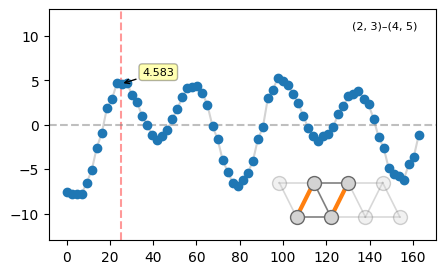

In [14]:
fig, ax = plt.subplots(figsize=(5, 3))

specific_correlation_pair = ((2,3),(4,5))
plot_correlation_time_data_and_sim(
    ax, 
    data, 
    coupling_point, 
    eigenstate,
    specific_correlation_pair,
    marker_size                 = 6,
    marker_edge                 = False,
    connect_scatter             = True,
    node_size                   = 100, 
    dephasing                   = dephasing, 
    plot_lattice                = True,
    simulation_config           = None, 
    y_lim                       = (-13,13), 
    compact                     = True,
    plot_zero_line              = True,
)
fig.patch.set_alpha(0)
plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_{str(specific_correlation_pair)}.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### 2.3 Plot All Uncondensed

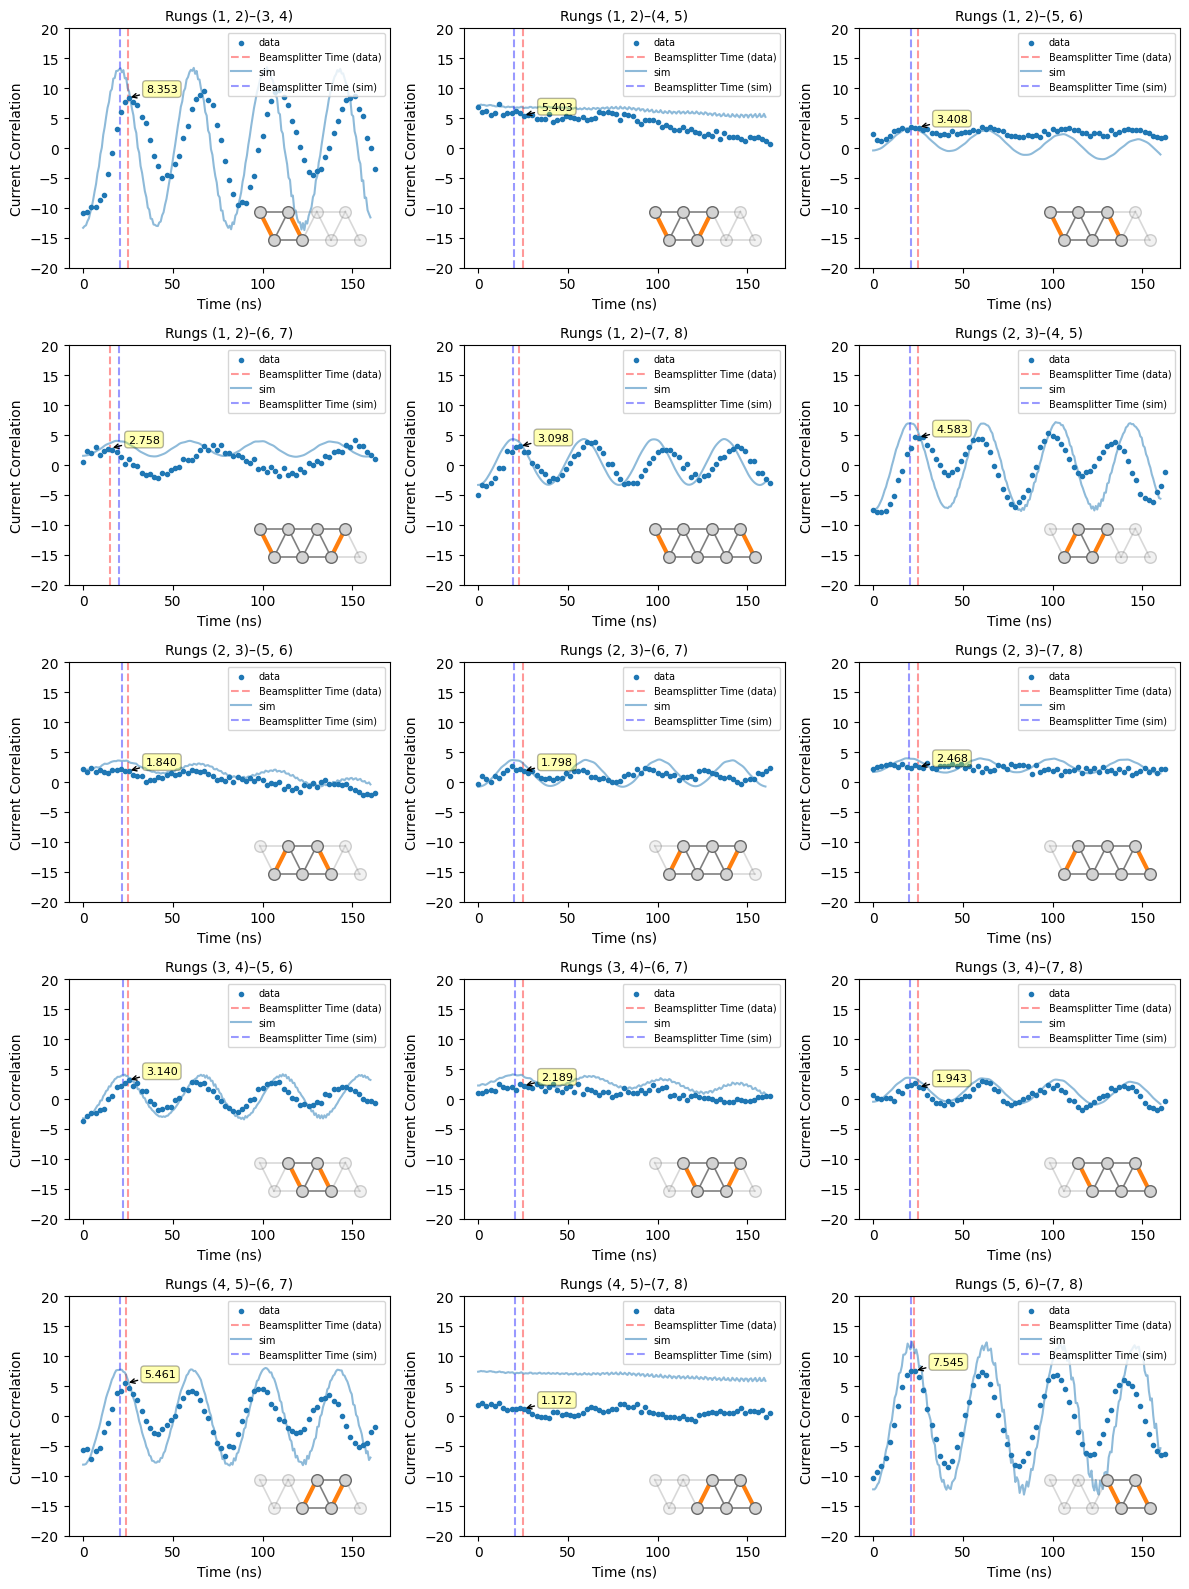

In [15]:
plot_correlation_time_grid(
    data                = data,
    coupling_point      = coupling_point,
    eigenstate          = eigenstate,
    correlation_pairs   = correlation_pairs,
    plot_lattice        = True, # False to not plot lattice
    simulation_config   = simulation_config, # None if don't want sim plotted
    nrows               = 5,
    ncols               = 3,
    marker_size         = 3,
    node_size           = 70,
    dephasing           = 'no_dephasing',
    y_lim               = (-20,20),
    compact             = False,
)

### 2.4 Plot Condensed Staircase Layout

In [16]:
def plot_correlation_data_and_sim_staircase(
    ax,
    data,
    coupling_point,
    eigenstate,
    correlation_pairs,
    dephasing,
    y_lim               = (-15,15),
    plot_lattice        = True,
    simulation_config   = None,
    marker_size         = 3,
    node_size           = 70,
    nrows               = 5,
    ncols               = 5,
    font_size           = 10
):
    fig = ax.figure
    # Get its position (in figure coordinates)
    left, bottom, width, height = ax.get_position().bounds

    # Remove the original axes
    ax.remove()

    # Create a new gridspec that fills exactly that same rectangle
    gs = fig.add_gridspec(
        nrows, ncols,
        left   = left,
        bottom = bottom,
        right  = left + width,
        top    = bottom + height,
        height_ratios=[1]*nrows
    )

    # axes for the small time-correlation plots
    axes_small = np.empty((nrows, ncols), dtype=object)
    for r in range(nrows):
        for c in range(ncols):
            axes_small[r, c] = fig.add_subplot(gs[r, c])

    used = np.zeros((nrows, ncols), dtype=bool)
    next_row_for_col = {r: 0 for r in range(nrows)}  # track next free col per row

    # Fill upper panels with time-correlation plots
    for idx, correlation_pair in enumerate(correlation_pairs):
        rung_index = correlation_pair[0][0] - 1
        row_idx = nrows - 1 - rung_index
        if row_idx < 0 or row_idx >= nrows:
            continue

        if row_idx not in next_row_for_col:
            next_row_for_col[row_idx] = 0

        col_idx = next_row_for_col[row_idx]
        if col_idx >= ncols:
            continue

        ax_main = axes_small[row_idx, col_idx]
        used[row_idx, col_idx] = True
        next_row_for_col[row_idx] += 1

        plot_correlation_time_data_and_sim(
            ax_main, data, coupling_point, eigenstate, correlation_pair,
            marker_size=marker_size, node_size=node_size, dephasing=dephasing, plot_lattice=plot_lattice,
            simulation_config=simulation_config, y_lim=y_lim, compact=True,
        )
        
    # Shared labels - cant get these to work generally
    # fig.text(0.50, 0.05, "Time (ns)", ha="center", fontsize=10)
    # fig.text(0.08, 0.50, "Current Correlation", va="center", rotation="vertical", fontsize=10)
    
    # Shared legend
    axes_small[0, -1].legend(*axes_small[0, 0].get_legend_handles_labels(), loc="upper left", fontsize=font_size-2)

    # Post-processing for upper grid: hide unused axes, shared ticks ----
    for r in range(nrows):
        for c in range(ncols):
            ax = axes_small[r, c]
            if not used[r, c]:
                ax.axis('off')
                continue
            if r != nrows - 1:
                ax.set_xlabel('')
                ax.set_xticklabels([])
                ax.tick_params(axis='x', which='both', bottom=False, top=False)
            if c != 0:
                ax.set_ylabel('')
                ax.set_yticklabels([])
                ax.tick_params(axis='y', which='both', left=False, right=False)
                
    fig.subplots_adjust(wspace=0.05, hspace=0.1)


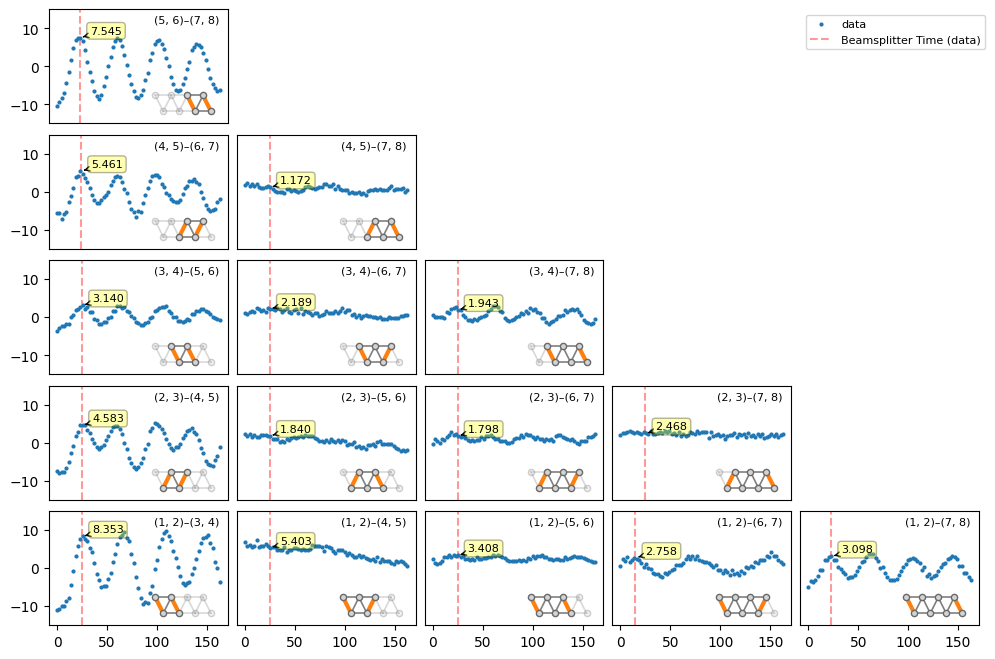

In [17]:
fig, ax = plt.subplots(figsize=(12,8))

plot_correlation_data_and_sim_staircase(
    ax,
    data                    = data,
    coupling_point          = coupling_point,
    eigenstate              = eigenstate,
    correlation_pairs       = correlation_pairs,
    dephasing               = dephasing,
    y_lim                   = (-15,15),
    plot_lattice            = True,                 # or False
    simulation_config       = None,    # or None to not plot sim
    marker_size             = 2,
    node_size               = 20,
    nrows                   = 5,
    ncols                   = 5
)
# plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_corrtimegrid.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Current Correlation vs Distance (Data and Sim)

In [18]:
def create_distance_to_data(data_block):
    distance_to_data = {}
    for correlation_pair in correlation_pairs:
        correlation_pair_data = data_block[str(correlation_pair)]
        current_correlation_value = correlation_pair_data['current_correlation_value']
        distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))

        if not distance in distance_to_data:
            distance_to_data[distance] = []
        
        distance_to_data[distance].append(current_correlation_value)
    return distance_to_data

def create_current_corr_averages(distance_to_data):
    current_correlation_averages = []
    for distance in distance_to_data:
        current_correlation_averages.append(np.mean(distance_to_data[distance]))
    return current_correlation_averages

def create_distances(distance_to_data):
    return [distance for distance in distance_to_data]

def plot_corr_vs_distance_with_valley(
    ax, 
    data, 
    coupling_point, 
    eigenstate, 
    correlation_pairs, 
    dephasing               = "no_dephasing",
    scatter_size            = 30,
    marker_size             = 4,
    plot_sim_data           = True,
    shade_sim_region        = False,
    shade_data_region       = False,
    y_lim                   = None,
    use_alphas              = True,
    alpha_floor             = 0.2,
    show_valley_colorbar    = True,
    sim_color               = "red",
    data_color              = "blue",
    label_prefix            = "",
    font_size               = 12
):
    try: 
        data_block = data["data"][coupling_point][eigenstate]
        try:
            distance_to_data = data_block['distance_to_current_correlation_value'] 
        except KeyError:
            distance_to_data = create_distance_to_data(data_block)
        try:
            distances = np.array(data_block["distances"], dtype=int)
        except KeyError:
            distances = create_distances(distance_to_data)
        try:
            avg_data = data_block["current_correlation_averages"]
        except KeyError:
            avg_data = create_current_corr_averages(distance_to_data)
        
        if plot_sim_data:
            try:
                sim_block  = data["simulation"][eigenstate][dephasing][coupling_point]
                try:
                    distances = np.array(sim_block["distances"], dtype=int)
                except:
                    distances = [2,3,4,5,6] # Manual
                distance_to_sim  = sim_block["distance_to_current_correlation_value_BS"]
                avg_sim  = sim_block["current_correlation_BS_averages"]
            except:
                plot_sim_data = False

    except KeyError as e:
        print(f"KeyError: {e}")
        return

    # Build (value, position) for data, grouped by int-distance
    # position = midpoint of the two rungs
    data_by_distance = {}  # d_int -> list of (value, pos)

    for cp in correlation_pairs:
        d   = abs(min(cp[0]) - min(cp[1]))
        pos = (min(cp[0]) + min(cp[1])) / 2.0
        val = data_block[str(cp)]["current_correlation_value"]

        if d not in data_by_distance:
            data_by_distance[d] = []
        data_by_distance[d].append((val, pos))


    # Collect all positions globally to define valley (median) and max spread
    all_positions = []
    for d in data_by_distance:
        all_positions.extend([pos for (_, pos) in data_by_distance[d]])
    all_positions = np.array(all_positions, dtype=float)

    if all_positions.size > 0:
        global_median     = np.median(all_positions)
        global_max_spread = np.max(np.abs(all_positions - global_median))
        pos_min           = all_positions.min()
        pos_max           = all_positions.max()
    else:
        global_median     = 0.0
        global_max_spread = 0.0
        pos_min           = 0.0
        pos_max           = 1.0

    # Helper: valley normalize on positions (0 at valley, 1 at edges),
    # then map into [alpha_floor, 1]
    if not use_alphas: alpha_floor = 1.0
    def valley_norm(pos_list):
        pos_list = np.array(pos_list, dtype=float)
        if global_max_spread == 0:
            return np.ones_like(pos_list)
        fracs = np.abs(pos_list - global_median) / global_max_spread  # 0 at valley
        return alpha_floor + (1.0 - alpha_floor) * fracs


    # I had to use these so it doesn't create duplicate labels in the legend
    first_sim  = True
    first_data = True

    # Plot sim + data points with valley-normalized alphas
    for d_str in sorted(distance_to_data.keys(), key=int):
        di = int(d_str)

        # positions & data values for this distance (one per correlation_pair)
        vals_pos  = data_by_distance[di]  # assume same number of pairs as sim values
        data_vals = [vp[0] for vp in vals_pos]
        positions = [vp[1] for vp in vals_pos]
        alphas    = valley_norm(positions)

        if plot_sim_data:
            sim_vals = distance_to_sim[d_str]
    
            # If lengths differ for some reason, fallback to uniform alpha
            if len(sim_vals) != len(alphas):
                sim_alphas = np.full(len(sim_vals), 0.7)
            else:
                sim_alphas = alphas

            for v, a in zip(sim_vals, sim_alphas):
                ax.scatter(di, v, color=sim_color, alpha=a, s=scatter_size, marker="^", label=f"{label_prefix} sim" if first_sim else None)
                first_sim = False

        for v, a in zip(data_vals, alphas):
            ax.scatter(di, v, color=data_color, alpha=a, s=scatter_size, label=f"{label_prefix} data" if first_data else None)
            first_data = False

    # Averages
    if plot_sim_data:
        ax.plot(distances, avg_sim, linestyle=":", color=sim_color, label=f"{label_prefix} sim avg")
    
    ax.plot(distances, avg_data, linestyle=":", color=data_color, markersize=marker_size, label=f"{label_prefix} data avg")


    # Precompute x_keys/x_num once if any region shading is requested
    if shade_sim_region or shade_data_region:
        x_keys = sorted(distance_to_data.keys(), key=int)
        x_num  = [int(d) for d in x_keys]

    if plot_sim_data:
        # Region shading for sim
        if shade_sim_region:
            sim_min = [np.min(distance_to_sim[d]) for d in x_keys]
            sim_max = [np.max(distance_to_sim[d]) for d in x_keys]
            ax.fill_between(x_num, sim_min, sim_max, color=sim_color, alpha=0.05, zorder=0)
        
    # Region shading for data
    if shade_data_region:
        data_min = [np.min(distance_to_data[str(d)]) for d in x_num]
        data_max = [np.max(distance_to_data[str(d)]) for d in x_num]
        ax.fill_between(x_num, data_min, data_max, color=data_color, alpha=0.05, zorder=0)

    if show_valley_colorbar and use_alphas:
        # Alpha legend: colorbar scaled by POSITION, with grayscale showing the alpha used there
        # We build a custom greyscale colormap where intensity matches the valley-normalized alpha.
        N_samples = 256
        pos_samples = np.linspace(pos_min, pos_max, N_samples)
    
        if global_max_spread == 0:
            alpha_samples = np.ones_like(pos_samples)
        else:
            fracs = np.abs(pos_samples - global_median) / global_max_spread
            alpha_samples = alpha_floor + (1.0 - alpha_floor) * fracs
            
        # alpha_samples: increases with distance (0 at valley -> low, edges -> high)
        # We want DARKER with distance, so intensity should DECREASE with distance
        intensity = 1.0 - alpha_samples
        
        colors = np.zeros((N_samples, 4))
        colors[:, 0] = intensity
        colors[:, 1] = intensity
        colors[:, 2] = intensity
        colors[:, 3] = 1.0  # keep the colorbar fully opaque

    
        cmap_pos = ListedColormap(colors)
        norm_pos = Normalize(vmin=pos_min, vmax=pos_max)
    
        sm = ScalarMappable(norm=norm_pos, cmap=cmap_pos)
        sm.set_array([])  # required by matplotlib
    
        cbar = plt.colorbar(sm, ax=ax, pad=0.03, fraction=0.035, use_gridspec=True)
        cbar.set_label("Midpoint (Saturation-level)")
    
    # Plot labels and title
    if y_lim:
        ax.set_ylim(y_lim[0], y_lim[1])
    ax.set_xlabel("Distance (rungs)", fontsize=font_size-2)
    ax.set_ylabel("Current Correlation", fontsize=font_size-2)
    ax.set_title("Correlation vs Distance", fontsize=font_size)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=font_size - 2)


In [19]:
def plot_correlation_decay(
    ax,
    data,
    coupling_point,
    eigenstate,
    plot_color  = "blue",
    fit_color   = "red",
    font_size   = 12
):
    distance_to_value_data = data['data'][coupling_point][eigenstate]['distance_to_current_correlation_value']
    current_correlation_averages_data = data['data'][coupling_point][eigenstate]['current_correlation_averages']
    
    raw_keys   = list(distance_to_value_data.keys())
    distances  = np.array(sorted(raw_keys, key=int), dtype=float)

    # Build avg_corr list matching these sorted distances
    avg_corr = []
    for d in distances:
        idx = int(d)
        avg_corr.append(current_correlation_averages_data[list(sorted(raw_keys, key=int)).index(str(idx))])
    avg_corr = np.array(avg_corr, dtype=float)
    
    # Calculate error bars
    std_corr = []
    for d in distances:
        vals = distance_to_value_data[str(int(d))]  # keys are likely strings
        std_corr.append(np.std(vals))
    std_corr = np.array(std_corr, dtype=float)
    
    # Plot data with error bars
    abs_avg_corr = np.abs(avg_corr)
    ax.errorbar(distances, abs_avg_corr, yerr=std_corr, marker='o', markersize=4, capsize=5, capthick=1, color=plot_color, ecolor="black", alpha=0.7, label='Data', elinewidth=1)
    
    # Fit exponential decay: C(d) = A * exp(-d/xi) + C0
    def decay_model(d, A, xi, C0):
        d = np.asarray(d, dtype=float)
        return A * np.exp(-d / xi) + C0
    
    try:
        # popt, pcov = curve_fit(decay_model, distances, abs_avg_corr, p0=[abs_avg_corr[0], 1.0, 0.0], maxfev=10000)
        
        popt, pcov = curve_fit(
            decay_model,
            distances,
            abs_avg_corr,
            p0=[abs_avg_corr[0], 5.0, 0.0],
            bounds=(
                [0.0, 0.5, -np.inf],   # A ≥ 0, xi ≥ 1 rung, C0 free
                [np.inf, 50.0, np.inf]
            ),
            maxfev=10000
        )
        
        A, xi, C0 = popt
        perr = np.sqrt(np.diag(pcov))
        
        # Plot fit
        d_fit = np.linspace(distances.min(), distances.max(), 100)
        fit_values = decay_model(d_fit, A, xi, C0)
        
        ax.plot(d_fit, fit_values, linestyle='--', color=fit_color, alpha=0.8)
        print(f'Fit: xi={xi:.2f}±{perr[1]:.2f}')
    except Exception as e:
        print(f"Fit failed: {e}")
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Distance (rungs)', fontsize=font_size - 2)
    ax.set_ylabel('|Correlation|', fontsize=font_size - 2)
    ax.set_title("Correlation Decay with Distance", fontsize=font_size)
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(True, alpha=0.3)


### 3.1 Plot Correlation vs Distance

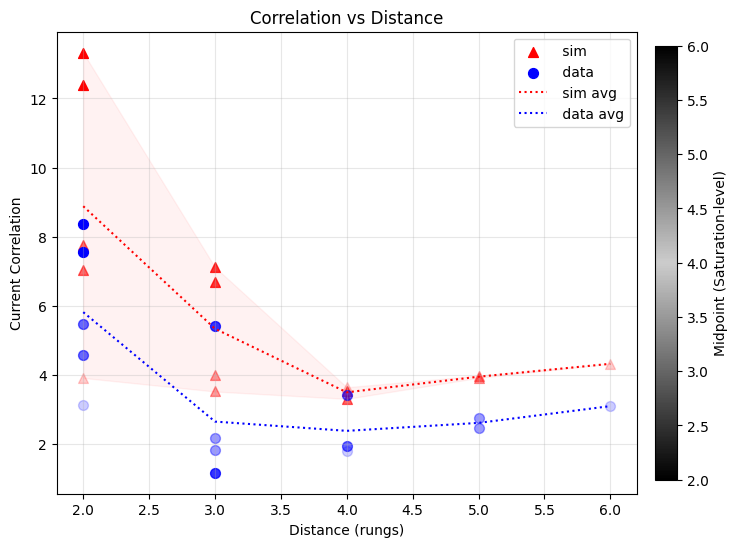

In [20]:
fig, ax = plt.subplots(figsize=(8,6))

plot_corr_vs_distance_with_valley(
    ax, 
    data, 
    coupling_point, 
    eigenstate, 
    correlation_pairs,
    dephasing               = dephasing,
    scatter_size            = 50,
    marker_size             = 4,
    plot_sim_data           = True, # To plot sim data or not
    shade_sim_region        = True,
    shade_data_region       = False,
    use_alphas              = True,  # To shade points with alpha according to position
    alpha_floor             = 0.2,
    show_valley_colorbar    = True,
    sim_color               = "red",
    data_color              = "blue",
)

# plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_corrvsdistance.png', dpi=300, bbox_inches='tight')
plt.show()


### 3.2 Plot Correlation Distance Decay

Fit: xi=0.50±0.34


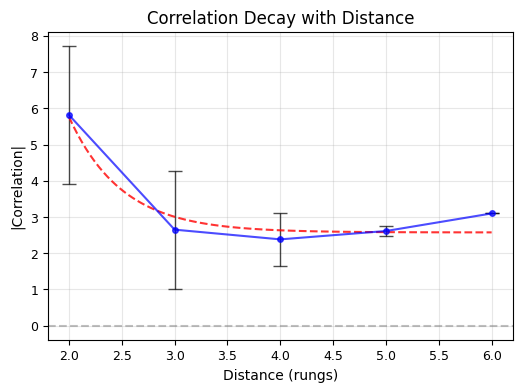

In [21]:
fig, ax = plt.subplots(figsize=(6,4))

plot_correlation_decay(
    ax,
    data,
    coupling_point,
    eigenstate,
    plot_color  = "blue",
    fit_color   = "red",
)

plt.show()

# 4. Plot Correlations vs Position

In [22]:
def plot_corr_vs_position_by_distance(
    ax,
    data,
    coupling_point,
    eigenstate,
    correlation_pairs,
    marker      ='o',
    linestyle   ='--',
    font_size    =12
):
    """
    Plot current correlation vs. position, grouped by rung-distance.
    Each distance gets its own curve on the same axes.
    """

    # Build mapping: distance -> {'correlation': [...], 'position': [...]}
    distance_to_current_correlation_vs_position = {
        d: {'correlation': [], 'position': []} for d in range(2, 7)
    }

    # Fill the mapping
    for cp in correlation_pairs:
        correlation_pair_data = data['data'][coupling_point][eigenstate][str(cp)]
        current_corr = correlation_pair_data['current_correlation_value']

        distance = abs(min(cp[0]) - min(cp[1]))
        position = (min(cp[0]) + min(cp[1])) / 2.0

        if distance in distance_to_current_correlation_vs_position:
            distance_to_current_correlation_vs_position[distance]['correlation'].append(current_corr)
            distance_to_current_correlation_vs_position[distance]['position'].append(position)

    # Plot each distance curve
    for distance, entry in distance_to_current_correlation_vs_position.items():
        ax.plot(
            entry['position'],
            entry['correlation'],
            marker=marker,
            linestyle=linestyle,
            label=f"d={distance}"
        )

    # Labels and styling
    ax.set_xlabel("Position (rungs)", fontsize=font_size - 2)
    ax.set_ylabel("Current Correlation", fontsize=font_size - 2)
    ax.set_title("Current Corr vs Position by Distances", fontsize=font_size)
    ax.legend(fontsize=font_size - 2)


### 4.1 Plot Correlation vs Position

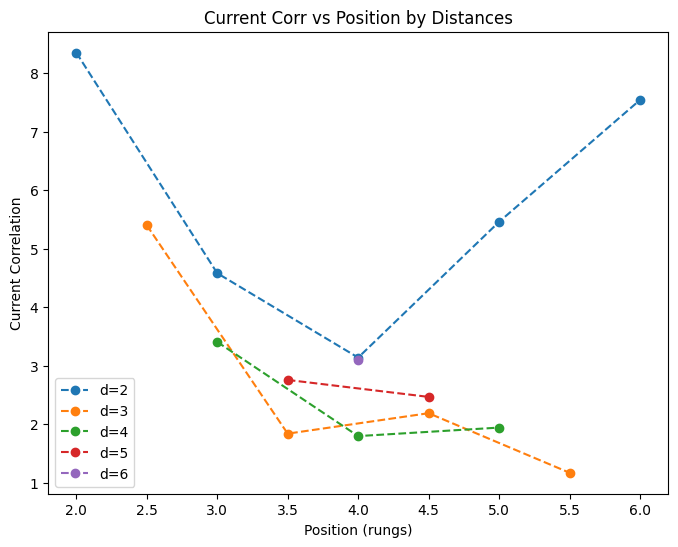

In [23]:
fig, ax = plt.subplots(figsize=(8,6))

plot_corr_vs_position_by_distance(
    ax=ax,
    data=data,
    coupling_point=coupling_point,
    eigenstate=eigenstate,
    correlation_pairs=correlation_pairs
)

plt.show()


# 5. Correlation Matrix Analysis

In [38]:
def build_correlation_matrix(data, coupling_point, eigenstate, dephasing=None, normalize=True):
    """
    Build correlation matrix for rung current correlations.
    If no dephasing is specified, it uses actual data. Otherwise, it uses simulation.
    """
    all_rungs = [(i, i+1) for i in range(1, 8)]
    N = len(all_rungs)
    corr_matrix = np.full((N, N), np.nan)
    rung_to_idx = {rung: i for i, rung in enumerate(all_rungs)}
    
    for correlation_pair in correlation_pairs:
        rung1, rung2 = correlation_pair
        i, j = rung_to_idx[rung1], rung_to_idx[rung2]
        
        # Branch based on data source
        if dephasing is None:
            pair_data = data['data'][coupling_point][eigenstate][str(correlation_pair)]
        else:
            pair_data = data['simulation'][eigenstate][dephasing][coupling_point][str(correlation_pair)]
        
        corr_val = pair_data['current_correlation_value']
        corr_matrix[i, j] = corr_val
        corr_matrix[j, i] = corr_val
    
    if normalize:
        max_val = np.nanmax(np.abs(corr_matrix))
        if max_val > 0:
            corr_matrix /= max_val
    
    return corr_matrix, all_rungs


def plot_corr_matrix(
    ax,
    corr_matrix,
    rungs,
    font_size=12,
    annotate_cells=True,
    title_prefix="",
    norm=None,
    nan_color="black",
    use_grid=False,
    hash_nan=True,
    hash_nan_color="white",
    grid_color="black",
):
    """Plot a correlation matrix on the given axes."""
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color=nan_color)

    im = ax.imshow(corr_matrix, cmap=cmap, norm=norm)
    
    if hash_nan:
        nan_mask = np.isnan(corr_matrix)
        nrows, ncols = corr_matrix.shape
        for i in range(nrows):
            for j in range(ncols):
                if nan_mask[i, j]:
                    ax.plot([j - 0.5, j + 0.5], [i + 0.5, i - 0.5], 
                            color=hash_nan_color, linewidth=0.5, zorder=10)
    
    ax.set_xticks(range(len(rungs)))
    ax.set_yticks(range(len(rungs)))
    ax.set_xticklabels([f"{r}" for r in rungs], rotation=45)
    ax.set_yticklabels([f"{r}" for r in rungs])
    ax.figure.colorbar(im, ax=ax, label='Correlation (J²)')
    
    if annotate_cells:
        vmax = norm.vmax if norm else np.nanmax(corr_matrix)
        vmin = norm.vmin if norm else np.nanmin(corr_matrix)
        for i in range(corr_matrix.shape[0]):
            for j in range(corr_matrix.shape[1]):
                val = corr_matrix[i, j]
                if np.isnan(val):
                    continue
                color = "white" if (val > vmax/2 or val < vmin/2) else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", 
                        color=color, fontsize=font_size-3)
    
    ax.set_xlabel("Rungs", fontsize=font_size-2)
    ax.set_ylabel("Rungs", fontsize=font_size-2)
    ax.set_title(f"{title_prefix} Rung Current Correlation Matrix", fontsize=font_size)
    ax.set_xticks(np.arange(-0.5, corr_matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, corr_matrix.shape[0], 1), minor=True)
    if use_grid:
        ax.grid(which="minor", color=grid_color, linestyle="-", linewidth=0.5)


def _compute_norm(matrices, floor=0.5):
    """Compute TwoSlopeNorm from one or more matrices."""
    all_vals = [m for m in matrices if m is not None]
    v_min = min(np.nanmin(all_vals), -floor)
    v_max = max(np.nanmax(all_vals), floor)
    return TwoSlopeNorm(vmin=v_min, vcenter=0, vmax=v_max)


def plot_data_corr_matrix(
    ax, 
    data, 
    coupling_point, 
    eigenstate, 
    font_size=12, 
    normalize=True, 
    annotate_cells=True,
    nan_color="black", 
    use_grid=False
):
    """Plot experimental data correlation matrix."""
    corr_matrix, rungs = build_correlation_matrix(
        data, coupling_point, eigenstate, dephasing=None, normalize=normalize)
    norm = _compute_norm([corr_matrix])
    plot_corr_matrix(ax, corr_matrix, rungs, font_size, annotate_cells, 
                     title_prefix="Data", nan_color=nan_color, use_grid=use_grid, norm=norm)


def plot_sim_corr_matrix(
    ax, 
    data, 
    coupling_point, 
    eigenstate, 
    dephasing,
    font_size=12, 
    normalize=True, 
    annotate_cells=True,
    nan_color="black"
):
    """Plot simulation correlation matrix."""
    corr_matrix, rungs = build_correlation_matrix(
        data, coupling_point, eigenstate, dephasing=dephasing, normalize=normalize)
    norm = _compute_norm([corr_matrix])
    plot_corr_matrix(ax, corr_matrix, rungs, font_size, annotate_cells,
                     title_prefix="Sim", nan_color=nan_color, norm=norm)


def plot_data_and_sim_corr_matrix(
    ax, 
    data, 
    coupling_point, 
    eigenstate, 
    dephasing,
    font_size=12, 
    normalize=True, 
    annotate_cells=True,
    use_same_vextrema=True, 
    nan_color="black",
    use_grid=False, 
    hash_nan=True, 
    hash_nan_color="white"
):
    """Plot data and simulation correlation matrices side by side."""
    # Split axes
    fig = ax.figure
    left, bottom, width, height = ax.get_position().bounds
    ax.remove()
    gs = fig.add_gridspec(1, 2, left=left, bottom=bottom, right=left+width, top=bottom+height)
    ax_data = fig.add_subplot(gs[0, 0])
    ax_sim = fig.add_subplot(gs[0, 1])

    # Build matrices
    data_corr, rungs = build_correlation_matrix(
        data, coupling_point, eigenstate, dephasing=None, normalize=normalize)
    sim_corr, _ = build_correlation_matrix(
        data, coupling_point, eigenstate, dephasing=dephasing, normalize=normalize)
    
    norm = _compute_norm([data_corr, sim_corr]) if use_same_vextrema else None
    
    common_kwargs = dict(font_size=font_size, annotate_cells=annotate_cells, norm=norm,
                         nan_color=nan_color, use_grid=use_grid, 
                         hash_nan=hash_nan, hash_nan_color=hash_nan_color)
    
    plot_corr_matrix(ax_data, data_corr, rungs, title_prefix="Data", **common_kwargs)
    plot_corr_matrix(ax_sim, sim_corr, rungs, title_prefix="Sim", **common_kwargs)

### 5.1 Plot Corr Matrix Data and Sim

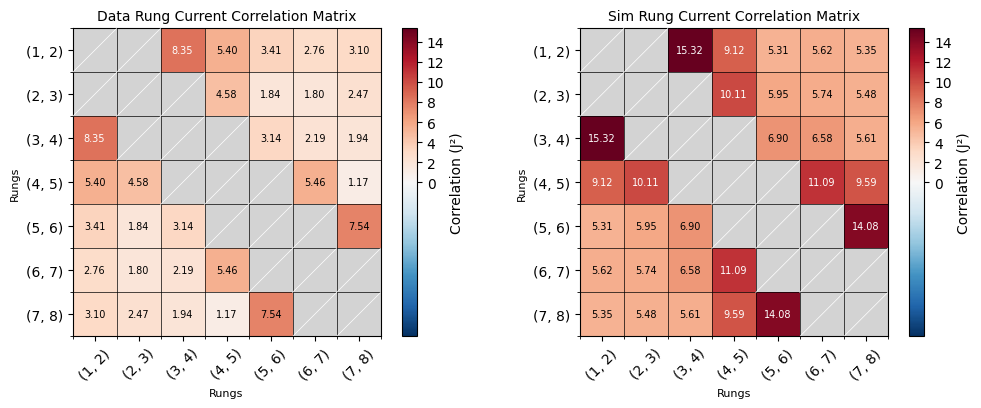

In [39]:
fig, ax = plt.subplots(figsize=(12, 4))

plot_data_and_sim_corr_matrix(
    ax,
    data,
    coupling_point,
    eigenstate,
    dephasing,
    normalize           = False,
    font_size           = 10,
    annotate_cells      = True,
    use_same_vextrema    = True,
    nan_color           = "lightgray",
    use_grid            = True,
    hash_nan            = True,
    hash_nan_color      = "white"
)

# plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_corrmatrix.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2 Plot Combined Corr Matrix

In [26]:
def build_combined_correlation_matrix(
    data, 
    coupling_point, 
    eigenstate, 
    dephasing,
    correlation_pairs,
    normalize       = True,
):
    """Build combined matrix: lower triangle = data, upper triangle = sim."""
    all_rungs = [(i, i+1) for i in range(1, 8)]
    N = len(all_rungs)
    combined_matrix = np.full((N, N), np.nan)
    rung_to_idx = {rung: i for i, rung in enumerate(all_rungs)}
    
    for correlation_pair in correlation_pairs:
        rung1, rung2 = correlation_pair
        i, j = rung_to_idx[rung1], rung_to_idx[rung2]
        
        # Data in lower triangle
        try:
            data_val = data['data'][coupling_point][eigenstate][str(correlation_pair)]['current_correlation_value']
            combined_matrix[max(i,j), min(i,j)] = data_val
        except KeyError:
            pass
        
        # Sim in upper triangle
        try:
            sim_val = data['simulation'][eigenstate][dephasing][coupling_point][str(correlation_pair)]['current_correlation_value']
            combined_matrix[min(i,j), max(i,j)] = sim_val
        except KeyError:
            pass
    
    if normalize:
        max_val = np.nanmax(np.abs(combined_matrix))
        if max_val > 0:
            combined_matrix /= max_val
    
    return combined_matrix, all_rungs


def plot_combined_corr_matrix(
    ax,
    data,
    coupling_point,
    eigenstate,
    dephasing,
    correlation_pairs,
    normalize       = True,
    font_size       = 12,
    annotate_cells  = True,
    nan_color       = "lightgray",
    use_grid        = True,
    hash_nan        = True,
    hash_nan_color  = "white",
    label_color     = "black",
    grid_color      = "black"
):
    """Plot combined matrix: lower triangle = data, upper triangle = sim."""
    combined_matrix, rungs = build_combined_correlation_matrix(
        data, coupling_point, eigenstate, dephasing, correlation_pairs, normalize=normalize
    )
    
    v_min = min(np.nanmin(combined_matrix), -0.5)
    v_max = max(np.nanmax(combined_matrix),  0.5)
    norm = TwoSlopeNorm(vmin=v_min, vcenter=0, vmax=v_max)
    
    plot_corr_matrix(
        ax, combined_matrix, rungs,
        font_size=font_size, 
        annotate_cells=annotate_cells,
        title_prefix="Data \\ Sim", 
        norm=norm,
        nan_color=nan_color, 
        use_grid=use_grid,
        hash_nan=hash_nan,
        hash_nan_color=hash_nan_color,
        grid_color=grid_color
    )
    
    # Diagonal line separating data/sim
    N = len(rungs)
    ax.plot([-0.5, N-0.5], [-0.5, N-0.5], '-', linewidth=1, zorder=5, color=label_color)
    
    # Labels
    ax.text(0.02, 0.98, "    Sim", transform=ax.transAxes, fontsize=font_size - 2,
            verticalalignment='top', zorder=10, color=label_color)
    ax.text(0.98, 0.02, "Data    ", transform=ax.transAxes, fontsize=font_size - 2,
            verticalalignment='bottom', horizontalalignment='right', zorder=10, color=label_color)
    

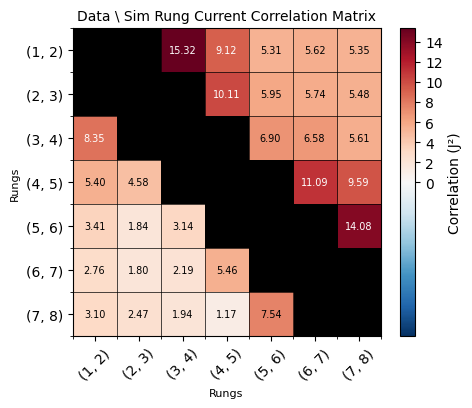

In [43]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_combined_corr_matrix(
    ax, data, coupling_point, eigenstate, dephasing, correlation_pairs,
    normalize           = False,    # noralize the data between 0 and 1?
    font_size           = 10,       # size of the font
    annotate_cells      = True,     # whether the cells should have the value shown in them
    nan_color           = "black",  # what the background color of the nan cells are
    use_grid            = True,     # Use a grid?
    grid_color          = "black",  # What color is the grid? (ignored if use_grid is False)
    hash_nan            = False,    # Whether to have hash marks through the nan cells
    label_color         = "white",  # What color the "data" and "sim" labels are (and the diagonal line)
)
fig.patch.set_alpha(0)
# plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_combined_corrmatrix.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

# 6. Full Summary Plot (1 Coupling Point, 1 Eigenstate)

### 6.1 Summary Plot

In [28]:
def create_summary_plot(
    plot_top,
    plot_bottom_wide,
    plots_bottom_small,
    top_kwargs=None,
    bottom_wide_kwargs=None,
    bottom_small_kwargs=None,
    figsize=(14, 12),
    height_ratios=(1, 2),
    wspace=0.25,
    hspace=0.5,
    top_hspace=0.15,
):
    """
    Layout:
      - Top: 1 wide plot
      - Bottom: [1 wide plot spanning full width]
                [3 small plots in a row underneath]

    plot_top : callable(ax, **kwargs)
    plot_bottom_wide : callable(ax, **kwargs)
    plots_bottom_small : list of up to 3 callables (use None for empty)
    """
    top_kwargs = top_kwargs or {}
    bottom_wide_kwargs = bottom_wide_kwargs or {}
    bottom_small_kwargs = bottom_small_kwargs or [{}, {}, {}]

    plots_bottom_small = list(plots_bottom_small) + [None] * (3 - len(plots_bottom_small))
    bottom_small_kwargs = list(bottom_small_kwargs) + [{}] * (3 - len(bottom_small_kwargs))

    fig = plt.figure(figsize=figsize)
    fig.suptitle(
        f"Current Correlations \n coupling point {coupling_point[-1]}, {eigenstate} eigenstate, {dephasing.replace('_', ' ')}",
        fontsize=12,
        y=0.92,
    )
    gs = GridSpec(2, 1, figure=fig, height_ratios=height_ratios, hspace=top_hspace)

    ax_top = fig.add_subplot(gs[0])
    plot_top(ax_top, **top_kwargs)

    bottom_gs = gs[1].subgridspec(2, 1, height_ratios=(1.5, 1.0), hspace=hspace)

    ax_bottom_wide = fig.add_subplot(bottom_gs[0])
    if plot_bottom_wide:
        plot_bottom_wide(ax_bottom_wide, **bottom_wide_kwargs)
    else:
        ax_bottom_wide.axis("off")

    small_gs = bottom_gs[1].subgridspec(1, 3, wspace=wspace)
    axes_bottom_small = []
    for i, (func, kwargs) in enumerate(zip(plots_bottom_small, bottom_small_kwargs)):
        ax = fig.add_subplot(small_gs[0, i])
        if func:
            func(ax, **kwargs)
        else:
            ax.axis("off")
        axes_bottom_small.append(ax)
        
    return fig, {
        "top": ax_top,
        "bottom_wide": ax_bottom_wide,
        "bottom_small": axes_bottom_small,
    }


Fit: xi=0.50±0.34


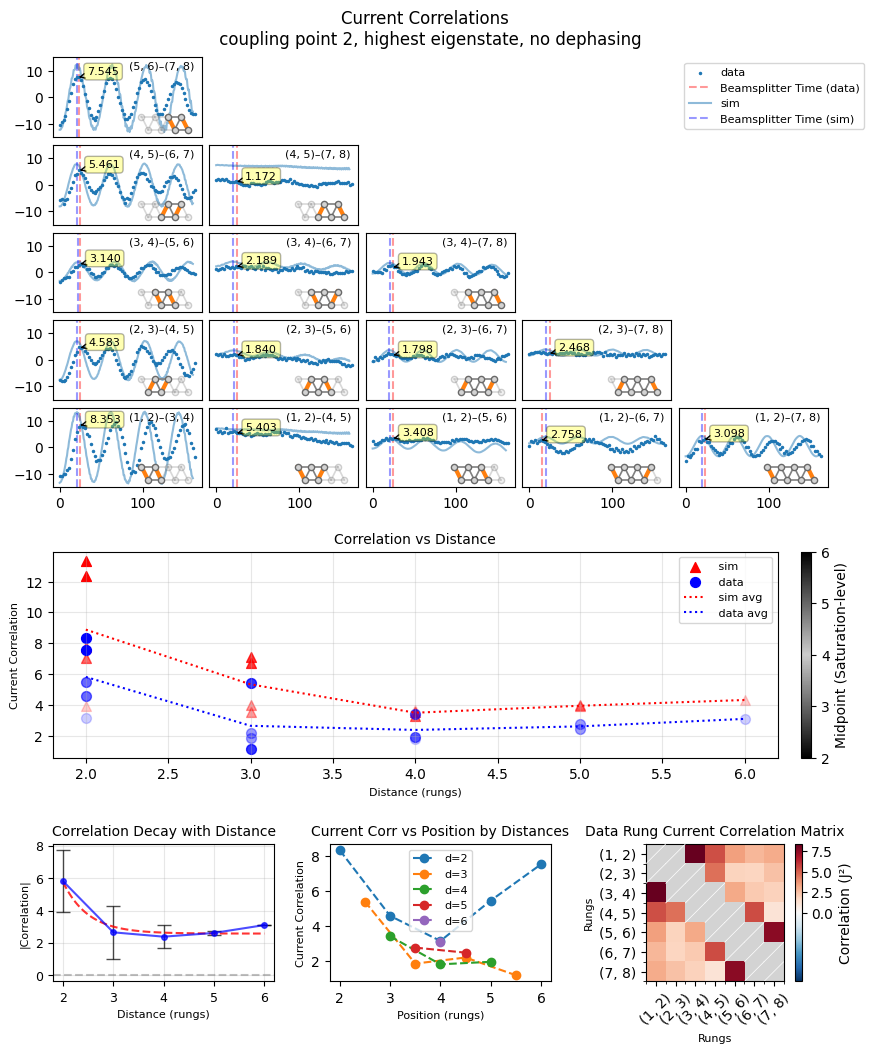

In [29]:
fig, axes = create_summary_plot(
    plot_top=plot_correlation_data_and_sim_staircase,
    plot_bottom_wide=plot_corr_vs_distance_with_valley,
    plots_bottom_small=[
        plot_correlation_decay,
        plot_corr_vs_position_by_distance,
        plot_data_corr_matrix,
    ],
    top_kwargs={
        'data'                    : data,
        'coupling_point'          : coupling_point,
        'eigenstate'              : eigenstate,
        'correlation_pairs'       : correlation_pairs,
        'dephasing'               : dephasing,
        'y_lim'                   : (-15,15),               # Set ylim of corr vs time plots
        'plot_lattice'            : True,                 # or False
        'simulation_config'       : simulation_config,    # or None
        'marker_size'             : 1.5,
        'node_size'               : 20,
        'nrows'                   : 5,
        'ncols'                   : 5,
    },
    bottom_wide_kwargs={
        'data': data, 
        'coupling_point'            : coupling_point, 
        'eigenstate'                : eigenstate, 
        'correlation_pairs'         : correlation_pairs,
        'dephasing'                 : dephasing,
        'y_lim'                     : None,                 # Can manually specify y_lim
        'font_size'                 : 10,
        'scatter_size'              : 50,
        'marker_size'               : 4,
        'plot_sim_data'             : True, # To plot sim data or not
        'shade_sim_region'          : False,
        'shade_data_region'         : False,
        'use_alphas'                : True,  # To shade points with alpha according to position
        'alpha_floor'               : 0.2,
        'show_valley_colorbar'      : True,
        'sim_color'                 : "red",
        'data_color'                : "blue",
    },
    bottom_small_kwargs=[
        {'data': data, 'coupling_point': coupling_point, 'eigenstate': eigenstate, 'font_size': 10},
        {'data': data, 'coupling_point': coupling_point, 'eigenstate': eigenstate, 'correlation_pairs': correlation_pairs, 'font_size': 10},
        {'data': data, 'coupling_point': coupling_point, 'eigenstate': eigenstate, 'font_size': 10,
         'normalize': False, 'annotate_cells': False, 'nan_color': 'lightgray', 'use_grid': False},
    ],
    figsize=(10, 12),
    height_ratios=(1.7, 1.7),
)

# plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_summary.png', dpi=300, bbox_inches='tight')
plt.show()


# 7. Across Eigenstate/Coupling Point Comparison

### 7.1 Eigenstate Comparison
Gets all possible eigenstates to plot for a coupling point and plots them.

In [30]:
def get_available_eigenstates(data, coupling_point):
    """Return list of available eigenstates for a coupling point."""
    try:
        return list(data['data'][coupling_point].keys())
    except KeyError:
        return []
    
def plot_correlation_distance_across_eigenstates(
    ax,
    data,
    coupling_point,
    correlation_pairs,
    dephasing,
    scatter_size            = 50,
    marker_size             = 4,
    plot_sim_data           = False,
    colors                  = []
):
    all_eigenstates = get_available_eigenstates(data, coupling_point)
    
    for idx, eigenstate in enumerate(all_eigenstates):
        plot_corr_vs_distance_with_valley(
            ax, 
            data, 
            coupling_point, 
            eigenstate, 
            correlation_pairs,
            dephasing               = dephasing,
            scatter_size            = 50,
            marker_size             = 4,
            plot_sim_data           = plot_sim_data, # To plot sim data or not
            shade_sim_region        = False,
            shade_data_region       = False,
            use_alphas              = False,  # To shade points with alpha according to position
            # alpha_floor             = 0.2, # Unused if use_alphas is false
            # show_valley_colorbar    = True, # Unsed - if you want it, set True only for the first eigenstate
            sim_color               = colors[idx] if idx < len(colors) else "red", # Unused if plot_sim_data is false
            data_color              = colors[idx] if idx < len(colors) else "blue",
            label_prefix            = f"eig={eigenstate[:3]}"
        )
    

Current Correlations: coupling point 2, no dephasing


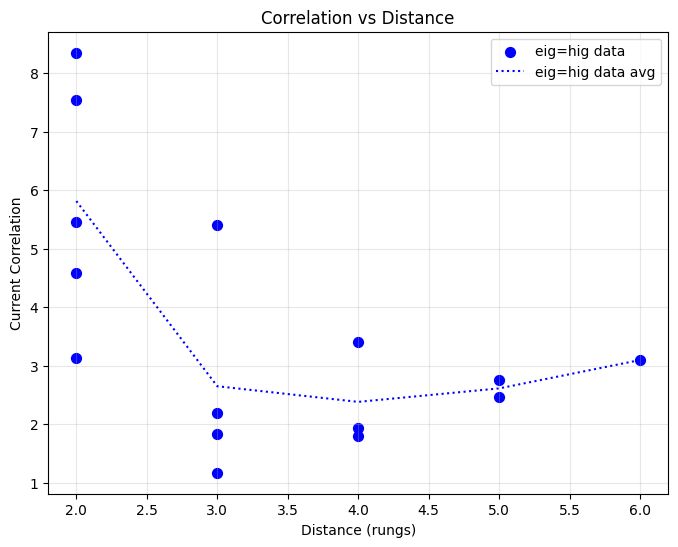

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_correlation_distance_across_eigenstates(
    ax,
    data,
    coupling_point,
    correlation_pairs,
    dephasing,
    scatter_size            = 50,
    marker_size             = 4,
    plot_sim_data           = False,
    colors                  = ["blue", "red"]
)

print(f"Current Correlations: coupling point {coupling_point[-1]}, {dephasing.replace('_', ' ')}")
# plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_eigens.png', dpi=300, bbox_inches='tight')
plt.show()

### 7.1 Coupling Point Comparison
Gets all possible coupling points to plot (fixed eigenstate).

In [32]:
def get_available_coupling_points(data):
    """Return list of available coupling points."""
    try:
        return list(data['data'].keys())
    except KeyError:
        return []

def plot_correlation_distance_across_coupling_points(
    ax,
    data,
    eigenstate,
    correlation_pairs,
    dephasing,
    scatter_size            = 50,
    marker_size             = 4,
    plot_sim_data           = False,
    colors                  = []
):
    all_coupling_points = get_available_coupling_points(data)
    
    for idx, coupling_point in enumerate(all_coupling_points):
        plot_corr_vs_distance_with_valley(
            ax, 
            data, 
            coupling_point, 
            eigenstate, 
            correlation_pairs,
            dephasing               = dephasing,
            scatter_size            = 50,
            marker_size             = 4,
            plot_sim_data           = plot_sim_data, # To plot sim data or not
            shade_sim_region        = False,
            shade_data_region       = False,
            use_alphas              = False,  # To shade points with alpha according to position
            # alpha_floor             = 0.2, # Unused if use_alphas is false
            # show_valley_colorbar    = True, # Unsed - if you want it, set True only for the first eigenstate
            sim_color               = colors[idx] if idx < len(colors) else "red", # Unused if plot_sim_data is false
            data_color              = colors[idx] if idx < len(colors) else "blue",
            label_prefix            = f"coup={coupling_point[-1]}"
        )
    

Current Correlations: highest eigenstate, no dephasing


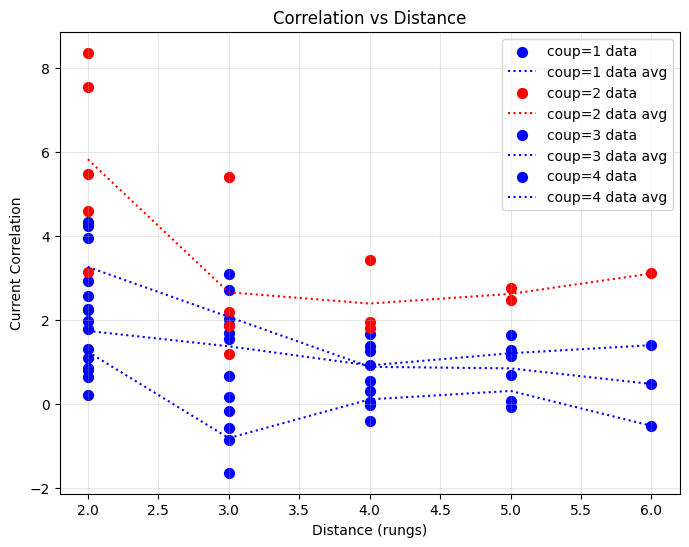

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_correlation_distance_across_coupling_points(
    ax,
    data,
    eigenstate,
    correlation_pairs,
    dephasing,
    scatter_size            = 50,
    marker_size             = 4,
    plot_sim_data           = False,
    colors                  = ["blue", "red"]
)

print(f"Current Correlations: {eigenstate} eigenstate, {dephasing.replace('_', ' ')}")
plt.show()

# 8. Correlation Asymmetry

In [34]:
def get_reflection_mapping():
    """
    Returns:
        reflection_pairs: List of tuples [(pair1, pair2), ...] that are related by reflection symmetry
        self_symmetric: List of pairs that map to themselves
    """
    all_pairs = []
    for i in range(1, 6):
        for j in range(i+2, 8):
            all_pairs.append(((i, i+1), (j, j+1)))
    
    def reflect_rung(rung):
        a, b = rung
        return (8 - b + 1, 9 - a)
    
    def reflect_pair(pair):
        rung1, rung2 = pair
        r1 = reflect_rung(rung1)
        r2 = reflect_rung(rung2)
        # Ensure smaller rung first
        if min(r1) > min(r2):
            r1, r2 = r2, r1
        return (r1, r2)
    
    reflection_pairs = []
    self_symmetric = []
    processed = set()
    
    for pair in all_pairs:
        if pair in processed:
            continue
            
        mirror = reflect_pair(pair)
        
        if mirror == pair:
            self_symmetric.append(pair)
            processed.add(pair)
        else:
            reflection_pairs.append((pair, mirror))
            processed.add(pair)
            processed.add(mirror)
    
    return reflection_pairs, self_symmetric


def compute_correlation_asymmetry(data, coupling_point, eigenstate):
    """
    Compute the correlation asymmetry for each reflection pair.
    For each pair of reflection-related correlations:
        delta = C_left - C_right
        where "left" is the pair closer to rung 1 and "right" is closer to rung 8.
    
    Returns:
        asymmetries dictionary: Dict mapping (pair_left, pair_right) -> delta value
        mean asymmetry
        asymetries_std: the standard deviation of the asymmetries
        self-symmetric rungs list
    """
    reflection_pairs, self_symmetric = get_reflection_mapping()
    
    data_block = data['data'][coupling_point][eigenstate]
    asymmetries = {}
    delta_values = []
    
    for pair_a, pair_b in reflection_pairs:
        pos_a = (min(pair_a[0]) + min(pair_a[1])) / 2
        pos_b = (min(pair_b[0]) + min(pair_b[1])) / 2
        
        if pos_a < pos_b:
            left_pair, right_pair = pair_a, pair_b
        else:
            left_pair, right_pair = pair_b, pair_a
        
        # Get correlation values
        C_left = data_block[str(left_pair)]['current_correlation_value']
        C_right = data_block[str(right_pair)]['current_correlation_value']
        
        delta = C_left - C_right
        asymmetries[(left_pair, right_pair)] = {
            'delta': delta,
            'C_left': C_left,
            'C_right': C_right,
            'position_left': left_pair,
            'position_right': right_pair,
        }
        delta_values.append(delta)
    
    asym_mean = np.mean(delta_values)
    asym_mean_std = np.std(delta_values) / np.sqrt(len(delta_values))  # Standard error
    
    return asymmetries, asym_mean, asym_mean_std, self_symmetric

def plot_asymmetry_bar_chart(ax, asymmetries, asym_mean, asym_mean_std):
    """
    Bar chart showing asymmetry delta for each reflection pair.
    """
    pairs = list(asymmetries.keys())
    deltas = [asymmetries[p]['delta'] for p in pairs]
    
    labels = []
    for (left, right) in pairs:
        l_str = f"{left[0]}-{left[1]}"
        r_str = f"{right[0]}-{right[1]}"
        labels.append(f"{l_str}\nvs\n{r_str}")
    
    colors = ['red' if d > 0 else 'blue' for d in deltas]
    
    ax.bar(range(len(deltas)), deltas, color=colors, alpha=0.7)
    
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(asym_mean, color='black', linestyle='--', linewidth=1, label=f'mean asymmetry = {asym_mean:.3f} ± {asym_mean_std:.3f}')
    ax.axhspan(asym_mean - asym_mean_std, asym_mean + asym_mean_std, alpha=0.2, color='gray')
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel('Asymmetry Delta (left - right)', fontsize=10)
    ax.set_xlabel('Reflection Pair (left vs right)', fontsize=10)
    ax.set_title('Correlation Asymmetry by Reflection Pair', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)


def plot_asymmetry_summary(ax, data, coupling_point, eigenstate):
    asymmetries, asym_mean, asym_mean_std, self_symmetric = compute_correlation_asymmetry(
        data, coupling_point, eigenstate
    )
        
    plot_asymmetry_bar_chart(ax, asymmetries, asym_mean, asym_mean_std)
    
    return asymmetries, asym_mean, asym_mean_std

### 8.1 Plot Asymmetry

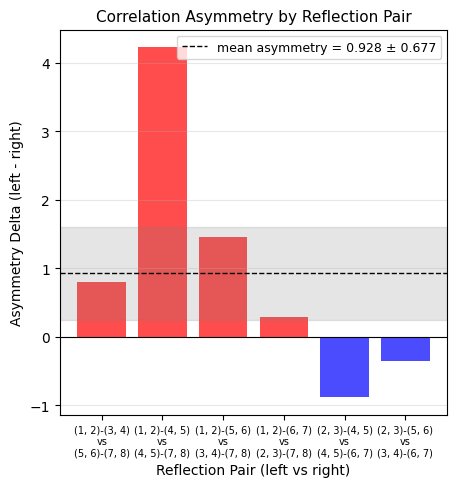

In [35]:
fig, ax = plt.subplots(figsize=(5, 5))

asymmetries, asym_mean, asym_mean_std = plot_asymmetry_summary(
    ax, 
    data, 
    coupling_point, 
    eigenstate
)

# plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_asymmetry.png', dpi=300, bbox_inches='tight')
plt.show()

# 9 Plot Total Chiral

In [36]:
def extract_chiral_current_data(
    data,
    eigenstate,
    dephasing,
    coupling_point_to_ratio,
):
    """Extract total chiral current data grouped by flux type."""
    result = {
        '0_flux': {'ratios': [], 'values': [], 'errors': [], 'sim_values': []},
        'pi_flux': {'ratios': [], 'values': [], 'errors': [], 'sim_values': []}
    }
    
    for cp, ratio in coupling_point_to_ratio.items():
        flux_type = '0_flux' if int(cp[-1]) in [4, 5, 6] else 'pi_flux'
        
        # Data
        if cp in data['data']:
            try:
                val = data['data'][cp][eigenstate]['current_correlation_total']
                err = data['data'][cp][eigenstate].get('current_correlation_total_error', 0)
                result[flux_type]['ratios'].append(ratio)
                result[flux_type]['values'].append(val)
                result[flux_type]['errors'].append(err)
            except KeyError:
                pass
        
        # Simulation
        try:
            sim_val = data['simulation'][eigenstate][dephasing][cp]['current_correlation_total']
            if cp in data['data']:  # only add sim if we have corresponding data
                result[flux_type]['sim_values'].append(sim_val)
        except KeyError:
            pass
    
    return result


def plot_chiral_current_vs_ratio(
    ax,
    data,
    eigenstate,
    dephasing,
    coupling_point_to_ratio,
    plot_sim        = False,
    use_abs         = True,
    marker_size     = 8,
    font_size       = 12,
    show_grid       = True,
):
    """Plot total chiral current vs coupling ratio."""
    params = extract_chiral_current_data(data, eigenstate, dephasing, coupling_point_to_ratio)
    
    transform = np.abs if use_abs else lambda x: x
    
    # 0 flux data
    if params['0_flux']['ratios']:
        ax.errorbar(
            params['0_flux']['ratios'],
            transform(params['0_flux']['values']),
            yerr=params['0_flux']['errors'],
            color='blue', marker='o', ms=marker_size, linestyle='',
            capsize=3, label='0 flux'
        )
    
    # pi flux data
    if params['pi_flux']['ratios']:
        ax.errorbar(
            params['pi_flux']['ratios'],
            transform(params['pi_flux']['values']),
            yerr=params['pi_flux']['errors'],
            color='red', marker='x', ms=marker_size, linestyle='',
            capsize=3, label='π flux'
        )
    
    # Simulation
    if plot_sim:
        if params['0_flux']['sim_values']:
            ax.plot(
                params['0_flux']['ratios'],
                transform(params['0_flux']['sim_values']),
                color='blue', linestyle=':', alpha=0.5, label='0 flux sim'
            )
        if params['pi_flux']['sim_values']:
            ax.plot(
                params['pi_flux']['ratios'],
                transform(params['pi_flux']['sim_values']),
                color='red', linestyle='--', alpha=0.5, label='π flux sim'
            )
            
    ax.axhline(0, linestyle='--', color="gray", linewidth=1.5)
    
    ax.set_xlabel('$J_{||}$/$J$', fontsize=font_size - 2)
    ax.set_xlim(0.85, 2.15)
    ax.set_ylim(-2, 40)
    ax.set_ylabel('Total Chiral Current ($J^2$)', fontsize=font_size - 2)
    ax.set_title('Total Chiral Current vs Coupling Ratio', fontsize=font_size)
    # ax.legend(fontsize=font_size - 2, loc='upper right')
    
    if show_grid:
        ax.grid(True, alpha=0.3)

### 9.1 Plot Chirals

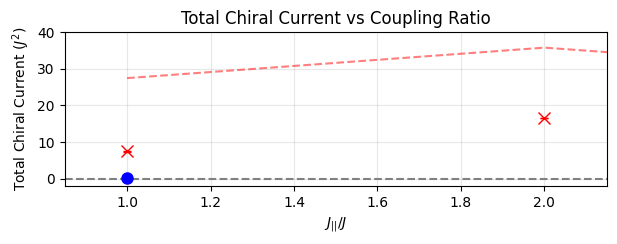

In [37]:
coupling_point_to_ratio = {
    'coupling_point_1': 1,
    'coupling_point_2': 2,
    'coupling_point_3': 3,
    'coupling_point_4': 1,
    'coupling_point_5': 2,
    'coupling_point_6': 4
}

fig, ax = plt.subplots(figsize=(7, 2))
plot_chiral_current_vs_ratio(
    ax, 
    data, 
    eigenstate, 
    dephasing, 
    coupling_point_to_ratio, 
    plot_sim=True
)

# plt.savefig(f'saved_figures/{eigenstate[:3]}_{dephasing}_totalchiralvsratio.png', dpi=300, bbox_inches='tight')
plt.show()